# County Scale Paper — Publication Figures

Self-contained. Reads the pipeline's `out/` CSVs and `data/` shapefiles, recomputes the piece-level
ledger internally, and writes every figure to `out/figures/` as **300 dpi PNG + vector PDF** with a
consistent journal style (panel letters, colour-blind-safe palette).

**Figure set (JSWC, county scale paper):**

| Fig | Content | Answers |
|---|---|---|
| 1 | Study design: counties vs HUC-8 boundaries + monitoring network | R1 map request, R3 boundary premise |
| 2 | County nitrogen load — choropleth + interannual series | core deliverable |
| 3 | Scale justification: HUC-8 / 10 / 12 coverage collapse | **R3 #4 (HUC-12)** |
| 4 | Administrative–hydrologic divergence: fragmentation + targeting | R3 #1 (measured, not asserted) |
| 5 | WQI priority-watershed coordination burden | R3 county-authority evidence |

Run top to bottom. If a shapefile path differs, edit `PATHS` in cell 1.

## 1. Style and inputs

In [1]:
import warnings; warnings.filterwarnings("ignore")
import os, numpy as np, pandas as pd, geopandas as gpd
import matplotlib as mpl, matplotlib.pyplot as plt
from matplotlib.lines import Line2D

CRS = "EPSG:26915"
PATHS = dict(
    counties = "data/Iowa_County_Boundaries/IowaCounties.shp",
    huc8     = "data/WBD_IA/WBD_HU_08_IA.shp",
    county_load = "out/county_year_load.csv",
    pieces      = "out/county_huc8_pieces.csv",
    flow_hm     = "out/huc8_month_flow.csv",
    conc_hm     = "out/huc8_month_conc.csv",
    gauge_sites = "cache/usgs_sites.csv",
    conc_file   = "data/concentration_data.csv",
    feasibility = "out/huc_feasibility_paired_spectrum.csv",  # 12-paired-month rows
)
FIGDIR = "out/figures"; os.makedirs(FIGDIR, exist_ok=True)

# ---- journal style ----
mpl.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 300,
    "font.family": "sans-serif", "font.sans-serif": ["Arial","DejaVu Sans"],
    "font.size": 9, "axes.titlesize": 10, "axes.labelsize": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titleweight": "bold", "axes.titlelocation": "left",
    "legend.frameon": False, "legend.fontsize": 8,
    "xtick.labelsize": 8, "ytick.labelsize": 8,
})
BLUE, RED, GREY, GREEN = "#2c6fbb", "#c2543d", "#6b6b6b", "#3f8f5b"
SEQ = "YlGnBu"

def save(fig, name):
    for ext in ("png","pdf"):
        fig.savefig(f"{FIGDIR}/{name}.{ext}", bbox_inches="tight")
    print(f"  saved {name}.png / .pdf")

def panel(ax, letter):
    ax.set_title(f"({letter})", loc="left", fontweight="bold")

KG_PER_MM_HA_PER_MGL = 0.01
YEARS = range(2001, 2020)

In [2]:
# ---- load ----
counties = gpd.read_file(PATHS["counties"])
counties = counties.rename(columns={next(c for c in ["CountyName","COUNTY","NAME","name"] if c in counties.columns):"CountyName"})
counties = counties.to_crs(CRS)[["CountyName","geometry"]].dissolve("CountyName").reset_index()

huc8 = gpd.read_file(PATHS["huc8"])
huc8 = huc8.rename(columns={next(c for c in ["HUC_8","HUC8","huc8"] if c in huc8.columns):"HUC_8"})
huc8["HUC_8"] = huc8["HUC_8"].astype(str).str.extract(r"(\d+)").iloc[:,0].str.zfill(8)
huc8 = huc8.to_crs(CRS)[["HUC_8","geometry"]].dissolve("HUC_8").reset_index()

cyl    = pd.read_csv(PATHS["county_load"])
pieces = pd.read_csv(PATHS["pieces"]); pieces["HUC_8"]=pieces["HUC_8"].astype(str).str.zfill(8)
flow   = pd.read_csv(PATHS["flow_hm"], dtype={"HUC_8":str})
conc   = pd.read_csv(PATHS["conc_hm"], dtype={"HUC_8":str})
print(f"counties {len(counties)} | HUC8 {len(huc8)} | county-load rows {len(cyl)} | pieces {len(pieces)}")

counties 99 | HUC8 57 | county-load rows 2058 | pieces 370


In [3]:
# ---- static piece ledger (matches Phase 3 v3): complete-HUC-year mean annual intensity ----
hm = flow.merge(conc, on=["HUC_8","Year","Month"], how="inner")
hm["load_kgha"] = hm["flow_mm"] * hm["conc_mgL"] * KG_PER_MM_HA_PER_MGL
hy = (hm.groupby(["HUC_8","Year"]).agg(load_kgha=("load_kgha","sum"),
                                       n_months=("Month","nunique")).reset_index())
hy = hy[(hy.Year.isin(YEARS)) & (hy.n_months == 12)]              # complete paired HUC-years only
mean_int = hy.groupby("HUC_8", as_index=False)["load_kgha"].mean().rename(columns={"load_kgha":"mean_intensity"})
L = pieces.merge(mean_int, on="HUC_8", how="inner")
L["piece_load_kg"] = L["mean_intensity"] * L["area_ha_piece"]     # static mean annual load
if "frac_of_county" not in L: L["frac_of_county"] = L.area_ha_piece / L.county_area_ha

# >=50% coverage primary screen (headline, per Methods)
if "mean_coverage_frac" in cyl.columns:
    ccov = cyl[cyl.Year.isin(YEARS)].groupby("CountyName").mean_coverage_frac.mean()
    prim_counties = set(ccov[ccov >= 0.5].index)
    Lp = L[L.CountyName.isin(prim_counties)].copy()
else:
    Lp = L.copy()
print(f"ledger: {len(L)} pieces, {L.HUC_8.nunique()} HUC8s (complete-year) | "
      f"primary (>=50% cov) counties: {Lp.CountyName.nunique()}")


ledger: 309 pieces, 39 HUC8s (complete-year) | primary (>=50% cov) counties: 90


## Figure 1 — Study design

  saved Fig1_study_design.png / .pdf


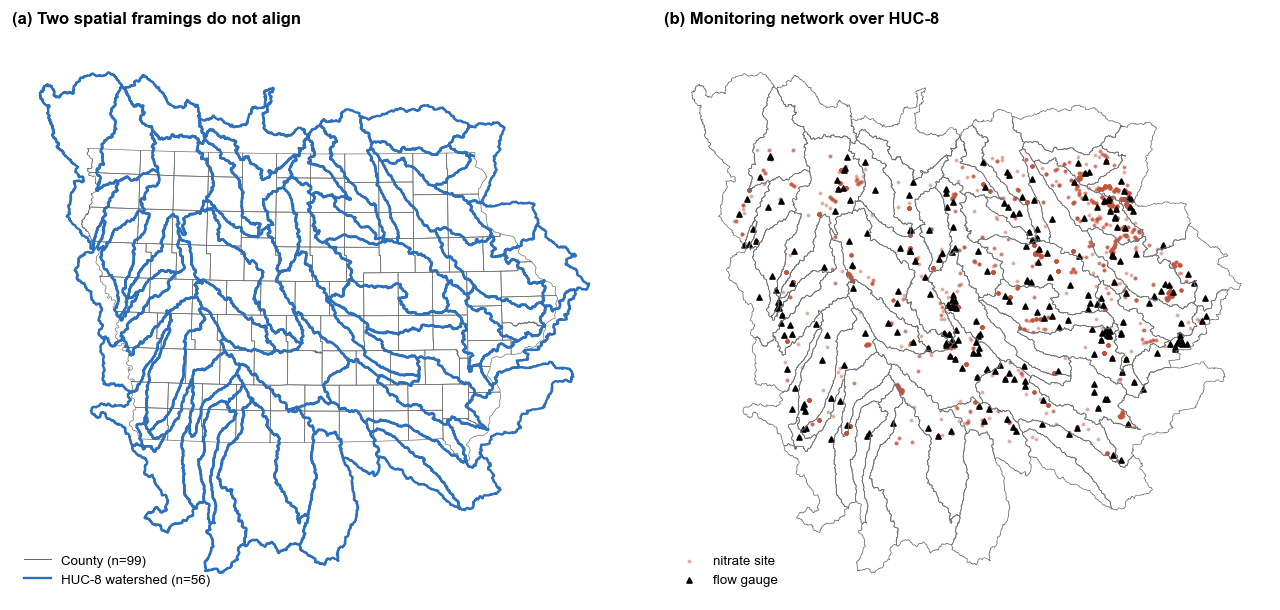

In [4]:
gs = pd.read_csv(PATHS["gauge_sites"], dtype={"site_no":str}).dropna(subset=["dec_lat_va","dec_long_va"])
gflow = gpd.GeoDataFrame(gs, geometry=gpd.points_from_xy(gs.dec_long_va, gs.dec_lat_va),
                         crs="EPSG:4326").to_crs(CRS)
dnr = pd.read_csv(PATHS["conc_file"])
dnr = dnr[dnr.get("type","").isin(["River/Stream"])] if "type" in dnr else dnr
dnr = dnr.dropna(subset=["latitude","longitude"])
gc = gpd.GeoDataFrame(dnr, geometry=gpd.points_from_xy(dnr.longitude, dnr.latitude),
                      crs="EPSG:4326").to_crs(CRS)

fig, ax = plt.subplots(1, 2, figsize=(11, 5))
# (a) two framings
counties.boundary.plot(ax=ax[0], color=GREY, lw=0.4)
huc8.boundary.plot(ax=ax[0], color=BLUE, lw=1.4)
ax[0].legend(handles=[Line2D([0],[0],color=GREY,lw=0.6,label="County (n=99)"),
                      Line2D([0],[0],color=BLUE,lw=1.4,label="HUC-8 watershed (n=56)")],
             loc="lower left")
ax[0].set_title("(a) Two spatial framings do not align", fontweight="bold")
# (b) monitoring network
huc8.boundary.plot(ax=ax[1], color=GREY, lw=0.4)
gc.sample(min(len(gc),4000), random_state=0).plot(ax=ax[1], color=RED, markersize=2, alpha=0.35, label="nitrate site")
gflow.plot(ax=ax[1], color="black", markersize=9, marker="^", label="flow gauge")
ax[1].legend(loc="lower left")
ax[1].set_title("(b) Monitoring network over HUC-8", fontweight="bold")
for a in ax: a.set_axis_off()
plt.tight_layout(); save(fig, "Fig1_study_design"); plt.show()

## Figure 2 — County nitrogen load

  saved Fig2_county_load.png / .pdf


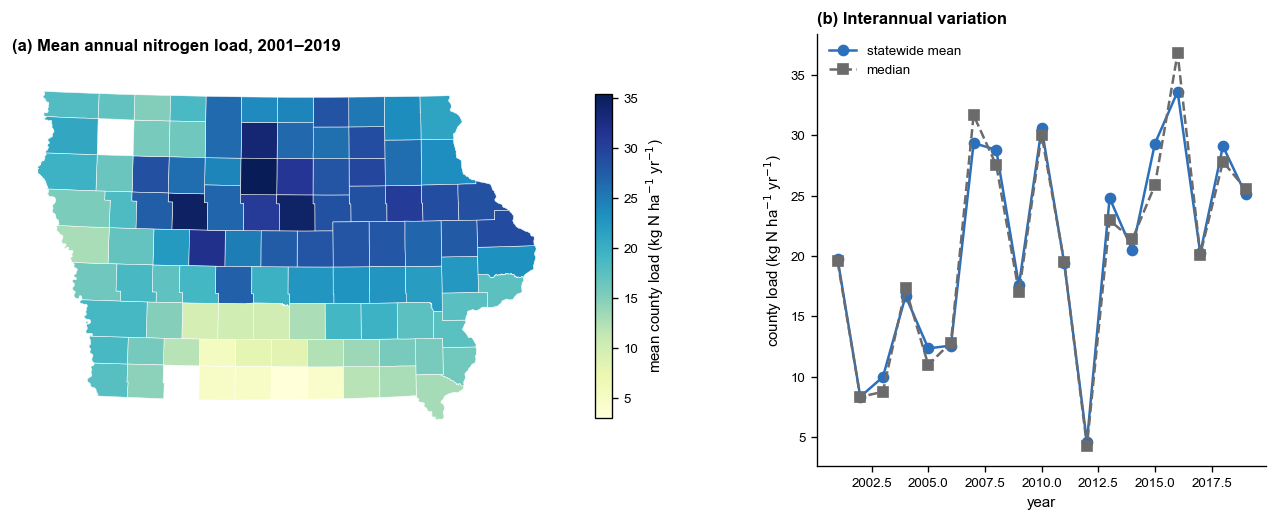

In [5]:
val = "loading_kgha" if "loading_kgha" in cyl else "load_kgha"
cy = cyl[cyl.Year.isin(YEARS)]
cmean = cy.groupby("CountyName", as_index=False)[val].mean()
gmap = counties.merge(cmean, on="CountyName", how="left")
yrser = cy.groupby("Year")[val].agg(["median","mean"])

fig = plt.figure(figsize=(11, 5))
axm = fig.add_axes([0.02, 0.05, 0.52, 0.9])
axl = fig.add_axes([0.63, 0.15, 0.34, 0.72])
gmap.plot(column=val, ax=axm, cmap=SEQ, legend=True, edgecolor="white", lw=0.3,
          legend_kwds={"label":"mean county load (kg N ha$^{-1}$ yr$^{-1}$)","shrink":0.6})
axm.set_title("(a) Mean annual nitrogen load, 2001–2019", fontweight="bold"); axm.set_axis_off()
axl.plot(yrser.index, yrser["mean"], "o-", color=BLUE, label="statewide mean")
axl.plot(yrser.index, yrser["median"], "s--", color=GREY, label="median")
axl.set_xlabel("year"); axl.set_ylabel("county load (kg N ha$^{-1}$ yr$^{-1}$)")
axl.legend(); axl.set_title("(b) Interannual variation", fontweight="bold")
save(fig, "Fig2_county_load"); plt.show()

## Figure 3 — Scale justification (HUC-8 / 10 / 12)

  saved Fig3_scale_justification.png / .pdf


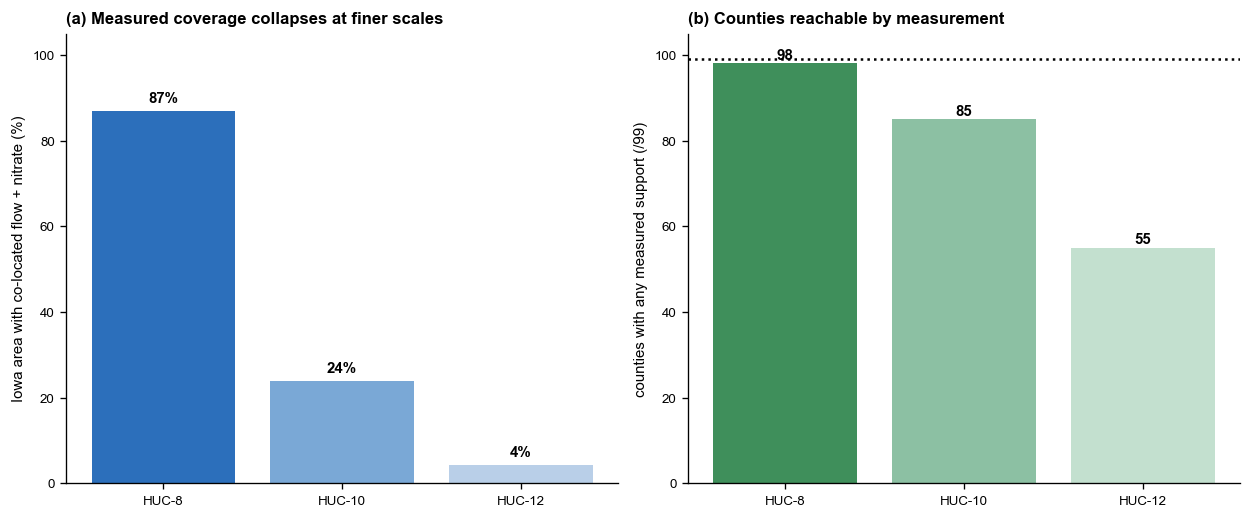

In [6]:
if os.path.exists(PATHS["feasibility"]):
    _f = pd.read_csv(PATHS["feasibility"])
    if "criterion" in _f.columns:                        # paired-month spectrum -> take complete rows
        _f = _f[_f.criterion.str.startswith("12")]
        feas = _f.rename(columns={"pct_area":"pct_area","counties":"counties"})[["scale","pct_area","counties"]]
    else:
        feas = _f
    # normalise expected columns
    acol = next((c for c in ["pct_iowa_area_both","pct_area_both"] if c in feas.columns), None)
    ccol = next((c for c in ["counties_with_any_spatial_support","counties_reached"] if c in feas.columns), None)
    scol = next((c for c in ["scale"] if c in feas.columns), None)
    feas = feas.rename(columns={acol:"pct_area", ccol:"counties", scol:"scale"})
else:
    feas = pd.DataFrame({"scale":["HUC-8","HUC-10","HUC-12"],
                         "median_unit_sqmi":[889.8,127.8,32.4],
                         "pct_area":[86.9,23.9,4.2], "counties":[98,85,55]})
    print("  (feasibility CSV not found — using values from your run)")

fig, ax = plt.subplots(1, 2, figsize=(10.5, 4.4))
x = np.arange(len(feas))
ax[0].bar(x, feas.pct_area, color=[BLUE, "#7aa8d6", "#b9cfe8"])
for i,v in enumerate(feas.pct_area): ax[0].text(i, v+2, f"{v:.0f}%", ha="center", fontweight="bold")
ax[0].set_xticks(x); ax[0].set_xticklabels(feas.scale)
ax[0].set_ylabel("Iowa area with co-located flow + nitrate (%)"); ax[0].set_ylim(0,105)
ax[0].set_title("(a) Measured coverage collapses at finer scales", fontweight="bold")
ax[1].bar(x, feas.counties, color=[GREEN, "#8cc0a3", "#c3e0cf"])
for i,v in enumerate(feas.counties): ax[1].text(i, v+1, f"{int(v)}", ha="center", fontweight="bold")
ax[1].axhline(99, ls=":", color="k"); ax[1].set_ylim(0,105)
ax[1].set_xticks(x); ax[1].set_xticklabels(feas.scale)
ax[1].set_ylabel("counties with any measured support (/99)")
ax[1].set_title("(b) Counties reachable by measurement", fontweight="bold")
plt.tight_layout(); save(fig, "Fig3_scale_justification"); plt.show()

## Figure 4 — Administrative–hydrologic divergence

  saved Fig4_divergence.png / .pdf


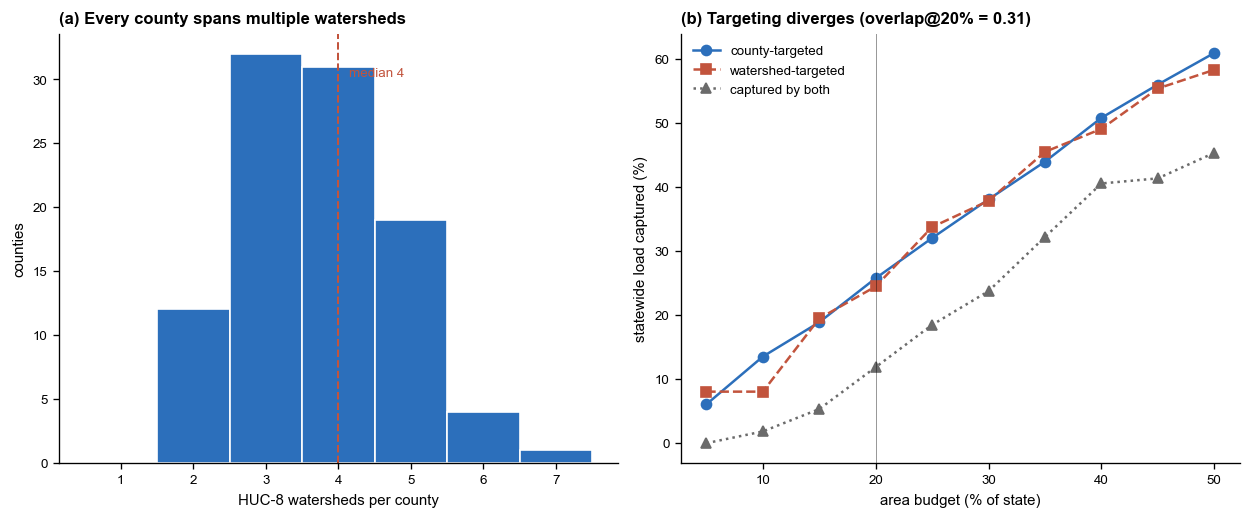

In [7]:
def targeting(L, b):
    tl = L.piece_load_kg.sum()
    ta = L.area_ha_piece.sum()                       # single area basis (harmonized)
    cty=L.groupby("CountyName").agg(load=("piece_load_kg","sum"),area=("area_ha_piece","sum")).reset_index().sort_values("load",ascending=False)
    cty["cum"]=cty.area.cumsum(); Sc=set(cty[cty.cum<=b*ta].CountyName) or {cty.CountyName.iloc[0]}
    huc=L.groupby("HUC_8").agg(load=("piece_load_kg","sum"),area=("area_ha_piece","sum")).reset_index().sort_values("load",ascending=False)
    huc["cum"]=huc.area.cumsum(); Sh=set(huc[huc.cum<=b*ta].HUC_8) or {huc.HUC_8.iloc[0]}
    cc=L[L.CountyName.isin(Sc)].piece_load_kg.sum()/tl; ch=L[L.HUC_8.isin(Sh)].piece_load_kg.sum()/tl
    both=L[L.CountyName.isin(Sc)&L.HUC_8.isin(Sh)].piece_load_kg.sum()/tl
    uni =L[L.CountyName.isin(Sc)|L.HUC_8.isin(Sh)].piece_load_kg.sum()/tl
    return cc,ch,both,(both/uni if uni else np.nan)

budgets = np.arange(0.05, 0.51, 0.05)
cur = np.array([targeting(Lp, b) for b in budgets])          # PRIMARY (>=50% coverage) for headline
hpc = pieces.groupby("CountyName").HUC_8.nunique()
ov20 = targeting(Lp, 0.20)[3]

fig, ax = plt.subplots(1, 2, figsize=(10.5, 4.4))
ax[0].hist(hpc, bins=np.arange(0.5, hpc.max()+1.5), color=BLUE, edgecolor="white")
ax[0].axvline(hpc.median(), color=RED, ls="--", lw=1.2)
ax[0].text(hpc.median()+0.15, ax[0].get_ylim()[1]*0.9, f"median {int(hpc.median())}", color=RED, fontsize=8)
ax[0].set_xlabel("HUC-8 watersheds per county"); ax[0].set_ylabel("counties")
ax[0].set_title("(a) Every county spans multiple watersheds", fontweight="bold")
ax[1].plot(budgets*100, cur[:,0]*100, "o-", color=BLUE, label="county-targeted")
ax[1].plot(budgets*100, cur[:,1]*100, "s--", color=RED, label="watershed-targeted")
ax[1].plot(budgets*100, cur[:,2]*100, "^:", color=GREY, label="captured by both")
ax[1].axvline(20, color="k", lw=0.6, alpha=0.4)
ax[1].set_xlabel("area budget (% of state)"); ax[1].set_ylabel("statewide load captured (%)")
ax[1].legend(loc="upper left")
ax[1].set_title(f"(b) Targeting diverges (overlap@20% = {ov20:.2f})", fontweight="bold")
plt.tight_layout(); save(fig, "Fig4_divergence"); plt.show()


## Figure 5 — WQI priority-watershed coordination burden

  saved Fig5_WQI_coordination.png / .pdf


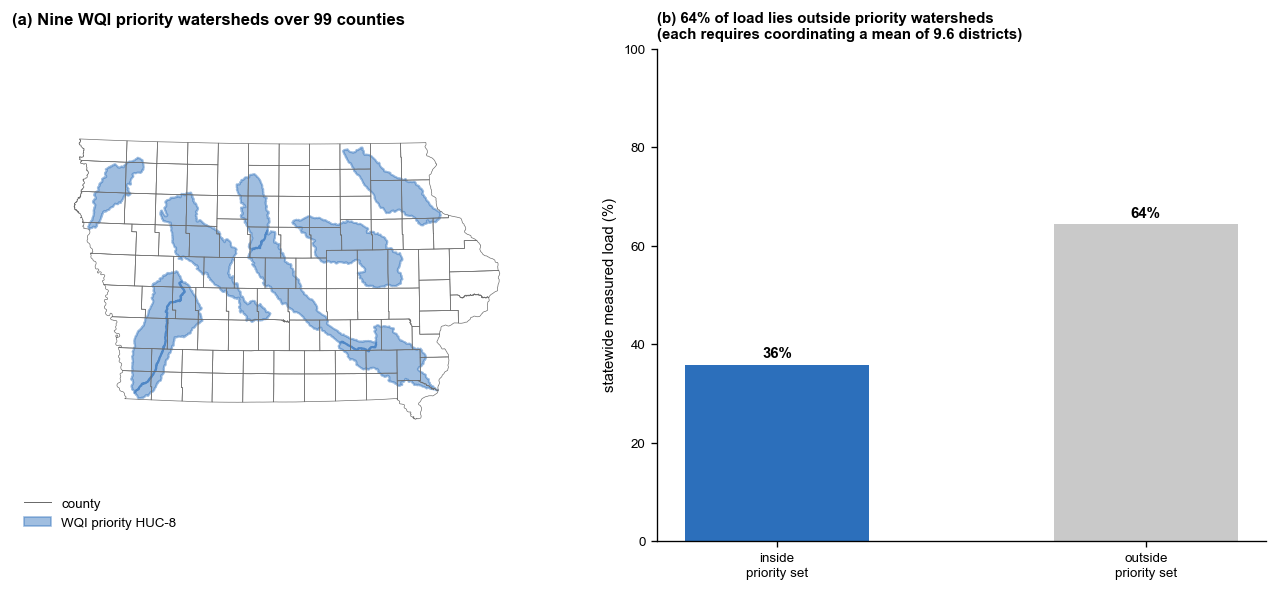


WQI matched 9/9 | load outside 64% | districts/watershed mean 9.6 max 15


In [8]:
WQI = {"Boone":"07100005","East Nishnabotna":"10240003","West Nishnabotna":"10240002",
       "Floyd":"10230002","South Skunk":"07080105","Middle Cedar":"07080205",
       "North Raccoon":"07100006","Skunk":"07080107","Turkey":"07060004"}   # verified crosswalk
codes = set(WQI.values())
present = codes & set(pieces.HUC_8)
tl = L.piece_load_kg.sum()
inw = L[L.HUC_8.isin(present)]
share_in = inw.piece_load_kg.sum()/tl
dpc = inw.groupby("HUC_8").CountyName.nunique()

fig, ax = plt.subplots(1, 2, figsize=(11, 5))
# (a) map: priority HUC8 + county overlay
counties.boundary.plot(ax=ax[0], color=GREY, lw=0.4)
huc8[huc8.HUC_8.isin(present)].plot(ax=ax[0], color=BLUE, alpha=0.45, edgecolor=BLUE, lw=1.2)
huc8.boundary.plot(ax=ax[0], color="none")
ax[0].set_title("(a) Nine WQI priority watersheds over 99 counties", fontweight="bold")
ax[0].set_axis_off()
ax[0].legend(handles=[Line2D([0],[0],color=GREY,lw=0.6,label="county"),
                      mpl.patches.Patch(color=BLUE,alpha=0.45,label="WQI priority HUC-8")],
             loc="lower left")
# (b) coordination + coverage bars
b1 = ax[1].bar([0,1],[share_in*100,(1-share_in)*100], color=[BLUE,"#c9c9c9"], width=0.5)
ax[1].set_xticks([0,1]); ax[1].set_xticklabels(["inside\npriority set","outside\npriority set"])
for i,v in enumerate([share_in*100,(1-share_in)*100]): ax[1].text(i,v+1.5,f"{v:.0f}%",ha="center",fontweight="bold")
ax[1].set_ylabel("statewide measured load (%)"); ax[1].set_ylim(0,100)
ax[1].set_title(f"(b) {(1-share_in)*100:.0f}% of load lies outside priority watersheds\n"
                f"(each requires coordinating a mean of {dpc.mean():.1f} districts)",
                fontweight="bold", fontsize=9)
plt.tight_layout(); save(fig, "Fig5_WQI_coordination"); plt.show()
print(f"\nWQI matched {len(present)}/9 | load outside {100*(1-share_in):.0f}% | "
      f"districts/watershed mean {dpc.mean():.1f} max {int(dpc.max())}")

## Export manifest

In [9]:
import glob
print("figures written to", FIGDIR)
for f in sorted(glob.glob(f"{FIGDIR}/*.png")):
    print("  ", os.path.basename(f))
print("\nEach has a matching .pdf (vector) for submission.")

figures written to out/figures
   Fig1_study_design.png
   Fig2_county_load.png
   Fig3_scale_justification.png
   Fig4_divergence.png
   Fig5_WQI_coordination.png

Each has a matching .pdf (vector) for submission.


## Notes

- **Colours** are colour-blind-safe (blue/red/green). Journals that require greyscale: the choropleth
  (`YlGnBu`) and all bars remain legible in mono.
- **Fig 3** reads `out/huc_scale_justification/huc_scale_coverage.csv` if present; otherwise it uses the
  values from your run (96 / 52 / 11%). Point `PATHS["feasibility"]` at the actual CSV to be exact.
- **Fig 1(b)** subsamples nitrate points for legibility; the count in the caption should cite the full
  n (all sites), not the plotted sample.
- To change figure width to a journal's column spec, edit the `figsize` in each cell; everything else
  scales.